### LIBRARY IMPORTS

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import copy
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier

if os.getcwd().endswith('notebooks'):
    os.chdir('..')

from src import *
from src.data_manager import DataManager
from src.processor import Processor
from src.nn_regressor import NNRegressor
from src.gb_classifier import GBClassifier

warnings.simplefilter(action='ignore', category=FutureWarning)

### CONFIGURATION

In [2]:
data_manager = DataManager()

datasets_config, modeling_config = data_manager.load_config()

active_dataset = modeling_config["main"]["active_dataset"]
active_dataset_config = datasets_config[active_dataset]
target = active_dataset_config["target"]

problem_type = active_dataset_config["problem_type"]

gradient_boosting_config = modeling_config["gradient_boosting"]

weak_learner_key = gradient_boosting_config["weak_learner_key"]
weak_learner_config = modeling_config[weak_learner_key]

processor = Processor(**active_dataset_config)

raw_train, raw_test = data_manager.load_raw_data()
raw_train = processor.cut_data(raw_train)

### STRATIFIED CROSS-VALIDATION

In [3]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def my_cross_validation(model, data, target, skf, processor):
    log_loss_scores = []
    accuracy_scores = []

    num_classes = len(np.unique(data[target]))
    oof_preds = np.zeros((len(data), num_classes), dtype=float)

    for train_idx, valid_idx in skf.split(data, data[target]):
        train_df = raw_train.iloc[train_idx]
        valid_df = raw_train.iloc[valid_idx]

        train_proc = processor.fit_transform(train_df)
        valid_proc = processor.transform(valid_df)

        X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
        X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

        model.fit(X_train, y_train)

        prob_preds = model.predict_proba(X_valid)
        class_preds = np.argmax(prob_preds, axis=1)
        
        oof_preds[valid_idx] = prob_preds

        fold_log_loss = log_loss(y_valid, prob_preds, labels=np.unique(y_train))
        fold_accuracy = accuracy_score(y_valid, class_preds)
        
        log_loss_scores.append(fold_log_loss)
        accuracy_scores.append(fold_accuracy)
    
    return log_loss_scores, accuracy_scores, oof_preds

### LOGISTIC REGRESSION

In [4]:
%%time

logistic = LogisticRegression()
logistic_log_loss_scores, logistic_accuracy_scores, logistic_oof_preds = my_cross_validation(logistic, raw_train, target, skf, processor)

CPU times: total: 2.34 s
Wall time: 1.33 s


In [5]:
print("Logistic regression log loss:", logistic_log_loss_scores)
print("Logistic regression accuracy:", logistic_accuracy_scores)

Logistic regression log loss: [0.2697083374586127, 0.2670589976179254, 0.2758899059085812, 0.27167092830671735, 0.2791858772055752]
Logistic regression accuracy: [0.8886, 0.89185, 0.88595, 0.88725, 0.88215]


### DECISION TREE

In [6]:
%%time

dt = DecisionTreeClassifier(max_depth=8, random_state=42)
dt_log_loss_scores, dt_accuracy_scores, dt_oof_preds = my_cross_validation(dt, raw_train, target, skf, processor)

CPU times: total: 1.8 s
Wall time: 1.82 s


In [7]:
print("Decision tree log loss:", dt_log_loss_scores)
print("Decision tree accuracy:", dt_accuracy_scores)

Decision tree log loss: [0.31276314707053077, 0.32082148168727054, 0.33522618765294904, 0.3178648168184856, 0.3160764151275917]
Decision tree accuracy: [0.8756, 0.87995, 0.87595, 0.87875, 0.87335]


### RANDOM FOREST

In [8]:
%%time

rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf_log_loss_scores, rf_accuracy_scores, rf_oof_preds = my_cross_validation(rf, raw_train, target, skf, processor)

CPU times: total: 19.3 s
Wall time: 19.4 s


In [9]:
print("Random forest log loss:", rf_log_loss_scores)
print("Random forest accuracy:", rf_accuracy_scores)

Random forest log loss: [0.29127511064551354, 0.2847866140934185, 0.29279612843141484, 0.2888345357233446, 0.2964171042556581]
Random forest accuracy: [0.88275, 0.8868, 0.8816, 0.8817, 0.8758]


### NEURAL NETWORK

In [10]:
class MLP(NNRegressor):
    def __init__(self, **hyperparameters):
        super().__init__(**hyperparameters)

    def fit(
        self,
        X_train: np.ndarray,
        y_train: np.ndarray,
        X_valid: np.ndarray,
        y_valid: np.ndarray, 
        patience: int = 10
    ) -> None:
        input_size = X_train.shape[1]
        
        unique_classes = np.unique(y_train)
        output_size = len(unique_classes)
        
        self._get_network(input_size, output_size)
        
        train_loader = self._prepare_loader(X_train, y_train)
        
        X_valid_t = torch.from_numpy(X_valid).to(torch.float32).to(self.device)
        y_valid_t = torch.from_numpy(y_valid).to(torch.long).to(self.device).squeeze()

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(self.parameters(), lr=self.learning_rate)
        
        best_loss = float('inf')
        best_model = None
        early_stop_count = 0

        for epoch in range(self.epochs):
            self.train()
            train_loss = 0
            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(self.device), batch_y.to(self.device)
                
                optimizer.zero_grad()
                preds = self(batch_X)
                loss = criterion(preds, batch_y.to(torch.long).to(self.device).squeeze())
                loss.backward()
                optimizer.step()
                train_loss += loss.item()

            self.eval()
            with torch.no_grad():
                val_preds = self(X_valid_t)
                val_loss = criterion(val_preds, y_valid_t).item()

                pred_labels = val_preds.argmax(dim=1)
                val_acc = (pred_labels == y_valid_t).float().mean().item()

            if (epoch + 1) % 1 == 0:
                print(f"Epoch: {epoch + 1} | Validation log loss: {val_loss:.4f} | Validation accuracy {val_acc:.4f}")

            if val_loss < best_loss:
                best_loss = val_loss
                best_model = copy.deepcopy(self.state_dict())
                early_stop_count = 0
            else:
                early_stop_count += 1

            if early_stop_count >= patience:
                break
                
        if best_model:
            self.load_state_dict(best_model)
    
    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        X_t = torch.from_numpy(X).to(torch.float32).to(self.device)
        self.eval()
        with torch.no_grad():
            logits = self.forward(X_t)
            predictions = torch.softmax(logits, dim=1)
        
        return predictions.cpu().numpy()

In [11]:
%%time

mlp = MLP(epochs=100, learning_rate=0.001, hidden_size=[16, 8], batch_size=1024)

mlp_log_loss_scores = []
mlp_accuracy_scores = []
num_classes = len(np.unique(raw_train[target]))
mlp_oof_preds = np.zeros((len(raw_train), num_classes), dtype=float)

for train_idx, valid_idx in skf.split(raw_train, raw_train[target]):
    train_df = raw_train.iloc[train_idx]
    valid_df = raw_train.iloc[valid_idx]

    train_proc = processor.fit_transform(train_df)
    valid_proc = processor.transform(valid_df)

    X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
    X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

    mlp.fit(X_train.values, y_train.values, X_valid.values, y_valid.values)

    prob_preds = mlp.predict_proba(X_valid.values)
    class_preds = np.argmax(prob_preds, axis=1)
    
    mlp_oof_preds[valid_idx] = prob_preds

    fold_log_loss = log_loss(y_valid, prob_preds, labels=np.unique(y_train))
    fold_accuracy = accuracy_score(y_valid, class_preds)
        
    mlp_log_loss_scores.append(fold_log_loss)
    mlp_accuracy_scores.append(fold_accuracy)

    print('-' * 50)

Epoch: 1 | Validation log loss: 0.4296 | Validation accuracy 0.8605
Epoch: 2 | Validation log loss: 0.3040 | Validation accuracy 0.8737
Epoch: 3 | Validation log loss: 0.2943 | Validation accuracy 0.8783
Epoch: 4 | Validation log loss: 0.2881 | Validation accuracy 0.8808
Epoch: 5 | Validation log loss: 0.2834 | Validation accuracy 0.8829
Epoch: 6 | Validation log loss: 0.2782 | Validation accuracy 0.8851
Epoch: 7 | Validation log loss: 0.2750 | Validation accuracy 0.8860
Epoch: 8 | Validation log loss: 0.2742 | Validation accuracy 0.8868
Epoch: 9 | Validation log loss: 0.2728 | Validation accuracy 0.8867
Epoch: 10 | Validation log loss: 0.2717 | Validation accuracy 0.8866
Epoch: 11 | Validation log loss: 0.2711 | Validation accuracy 0.8883
Epoch: 12 | Validation log loss: 0.2704 | Validation accuracy 0.8879
Epoch: 13 | Validation log loss: 0.2702 | Validation accuracy 0.8885
Epoch: 14 | Validation log loss: 0.2710 | Validation accuracy 0.8873
Epoch: 15 | Validation log loss: 0.2698 | V

In [12]:
print("Neural network log loss:", mlp_log_loss_scores)
print("Neural network accuracy:", mlp_accuracy_scores)

Neural network log loss: [0.26964487547207794, 0.266968898795137, 0.27547543378853195, 0.271319238711894, 0.27924312211999625]
Neural network accuracy: [0.8888, 0.89145, 0.88625, 0.88685, 0.88255]


### GRADIENT BOOSTING (DTs)

In [13]:
%%time

gb_log_loss_scores = []
gb_accuracy_scores = []
num_classes = len(np.unique(raw_train[target]))
gb_oof_preds = np.zeros((len(raw_train), num_classes), dtype=float)

for train_idx, valid_idx in skf.split(raw_train, raw_train[target]):
    train_df = raw_train.iloc[train_idx]
    valid_df = raw_train.iloc[valid_idx]

    train_proc = processor.fit_transform(train_df)
    valid_proc = processor.transform(valid_df)

    X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
    X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

    gb = GBClassifier(
        n_estimators=1000,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        early_stopping_rounds=10,
        weak_learner_key="decision_tree",
        weak_learner_config={"max_depth": 8, "random_state": 42}
    )
    
    gb.fit(X_train.values, y_train.values, X_valid.values, y_valid.values)

    prob_preds = gb.predict_proba(X_valid.values)
    class_preds = np.argmax(prob_preds, axis=1)
    
    gb_oof_preds[valid_idx] = prob_preds

    fold_log_loss = log_loss(y_valid, prob_preds, labels=np.unique(y_train))
    fold_accuracy = accuracy_score(y_valid, class_preds)
    
    gb_log_loss_scores.append(fold_log_loss)
    gb_accuracy_scores.append(fold_accuracy)
    
    print('-' * 50)

2026-04-24 09:11:18,708 - INFO - Iteration: 10 | Validation Log Loss: 0.511397 | Validation Accuracy: 0.876350
2026-04-24 09:11:20,493 - INFO - Iteration: 20 | Validation Log Loss: 0.422680 | Validation Accuracy: 0.882500
2026-04-24 09:11:22,185 - INFO - Iteration: 30 | Validation Log Loss: 0.374621 | Validation Accuracy: 0.883650
2026-04-24 09:11:23,892 - INFO - Iteration: 40 | Validation Log Loss: 0.345775 | Validation Accuracy: 0.884850
2026-04-24 09:11:25,606 - INFO - Iteration: 50 | Validation Log Loss: 0.326760 | Validation Accuracy: 0.886550
2026-04-24 09:11:27,308 - INFO - Iteration: 60 | Validation Log Loss: 0.314190 | Validation Accuracy: 0.887200
2026-04-24 09:11:29,051 - INFO - Iteration: 70 | Validation Log Loss: 0.305386 | Validation Accuracy: 0.887200
2026-04-24 09:11:30,866 - INFO - Iteration: 80 | Validation Log Loss: 0.299019 | Validation Accuracy: 0.887200
2026-04-24 09:11:32,582 - INFO - Iteration: 90 | Validation Log Loss: 0.294184 | Validation Accuracy: 0.887700
2

--------------------------------------------------


2026-04-24 09:12:37,930 - INFO - Iteration: 10 | Validation Log Loss: 0.509547 | Validation Accuracy: 0.882700
2026-04-24 09:12:39,666 - INFO - Iteration: 20 | Validation Log Loss: 0.420966 | Validation Accuracy: 0.888650
2026-04-24 09:12:41,476 - INFO - Iteration: 30 | Validation Log Loss: 0.371733 | Validation Accuracy: 0.889950
2026-04-24 09:12:43,166 - INFO - Iteration: 40 | Validation Log Loss: 0.343011 | Validation Accuracy: 0.889800
2026-04-24 09:12:44,875 - INFO - Iteration: 50 | Validation Log Loss: 0.324308 | Validation Accuracy: 0.890550
2026-04-24 09:12:46,561 - INFO - Iteration: 60 | Validation Log Loss: 0.311793 | Validation Accuracy: 0.890600
2026-04-24 09:12:48,350 - INFO - Iteration: 70 | Validation Log Loss: 0.302962 | Validation Accuracy: 0.890600
2026-04-24 09:12:50,080 - INFO - Iteration: 80 | Validation Log Loss: 0.296511 | Validation Accuracy: 0.891000
2026-04-24 09:12:51,875 - INFO - Iteration: 90 | Validation Log Loss: 0.291595 | Validation Accuracy: 0.891050
2

--------------------------------------------------


2026-04-24 09:13:40,381 - INFO - Iteration: 10 | Validation Log Loss: 0.510617 | Validation Accuracy: 0.878950
2026-04-24 09:13:42,083 - INFO - Iteration: 20 | Validation Log Loss: 0.423893 | Validation Accuracy: 0.882750
2026-04-24 09:13:43,791 - INFO - Iteration: 30 | Validation Log Loss: 0.375035 | Validation Accuracy: 0.883800
2026-04-24 09:13:45,354 - INFO - Iteration: 40 | Validation Log Loss: 0.346869 | Validation Accuracy: 0.884800
2026-04-24 09:13:47,118 - INFO - Iteration: 50 | Validation Log Loss: 0.328756 | Validation Accuracy: 0.885300
2026-04-24 09:13:48,922 - INFO - Iteration: 60 | Validation Log Loss: 0.316690 | Validation Accuracy: 0.884950
2026-04-24 09:13:50,677 - INFO - Iteration: 70 | Validation Log Loss: 0.308357 | Validation Accuracy: 0.885100
2026-04-24 09:13:52,273 - INFO - Iteration: 80 | Validation Log Loss: 0.302451 | Validation Accuracy: 0.885550
2026-04-24 09:13:54,010 - INFO - Iteration: 90 | Validation Log Loss: 0.298057 | Validation Accuracy: 0.885350
2

--------------------------------------------------


2026-04-24 09:14:36,516 - INFO - Iteration: 10 | Validation Log Loss: 0.510468 | Validation Accuracy: 0.881300
2026-04-24 09:14:38,234 - INFO - Iteration: 20 | Validation Log Loss: 0.423553 | Validation Accuracy: 0.884850
2026-04-24 09:14:39,941 - INFO - Iteration: 30 | Validation Log Loss: 0.374019 | Validation Accuracy: 0.886300
2026-04-24 09:14:41,647 - INFO - Iteration: 40 | Validation Log Loss: 0.344571 | Validation Accuracy: 0.886900
2026-04-24 09:14:43,357 - INFO - Iteration: 50 | Validation Log Loss: 0.325902 | Validation Accuracy: 0.886600
2026-04-24 09:14:45,001 - INFO - Iteration: 60 | Validation Log Loss: 0.313397 | Validation Accuracy: 0.886950
2026-04-24 09:14:46,576 - INFO - Iteration: 70 | Validation Log Loss: 0.304821 | Validation Accuracy: 0.886850
2026-04-24 09:14:48,275 - INFO - Iteration: 80 | Validation Log Loss: 0.298529 | Validation Accuracy: 0.887150
2026-04-24 09:14:50,006 - INFO - Iteration: 90 | Validation Log Loss: 0.293761 | Validation Accuracy: 0.887300
2

--------------------------------------------------


2026-04-24 09:15:36,357 - INFO - Iteration: 10 | Validation Log Loss: 0.510291 | Validation Accuracy: 0.876000
2026-04-24 09:15:38,123 - INFO - Iteration: 20 | Validation Log Loss: 0.424656 | Validation Accuracy: 0.881750
2026-04-24 09:15:39,907 - INFO - Iteration: 30 | Validation Log Loss: 0.377022 | Validation Accuracy: 0.883050
2026-04-24 09:15:41,585 - INFO - Iteration: 40 | Validation Log Loss: 0.348903 | Validation Accuracy: 0.883450
2026-04-24 09:15:43,328 - INFO - Iteration: 50 | Validation Log Loss: 0.331046 | Validation Accuracy: 0.882650
2026-04-24 09:15:45,043 - INFO - Iteration: 60 | Validation Log Loss: 0.319176 | Validation Accuracy: 0.882300
2026-04-24 09:15:46,731 - INFO - Iteration: 70 | Validation Log Loss: 0.310848 | Validation Accuracy: 0.882400
2026-04-24 09:15:48,437 - INFO - Iteration: 80 | Validation Log Loss: 0.304842 | Validation Accuracy: 0.883050
2026-04-24 09:15:50,142 - INFO - Iteration: 90 | Validation Log Loss: 0.300269 | Validation Accuracy: 0.883250
2

--------------------------------------------------
CPU times: total: 5min 26s
Wall time: 5min 26s


In [14]:
print("Gradient boosting (DTs) log loss:", gb_log_loss_scores)
print("Gradient boosting (DTs) accuracy:", gb_accuracy_scores)

Gradient boosting (DTs) log loss: [0.2721935073378004, 0.2713117292611921, 0.2798761870665323, 0.27487270987879414, 0.2822075716665952]
Gradient boosting (DTs) accuracy: [0.8879, 0.89055, 0.8866, 0.88755, 0.88225]


### XGBOOST

In [15]:
%%time

xgb_log_loss_scores = []
xgb_accuracy_scores = []
num_classes = len(np.unique(raw_train[target]))
xgb_oof_preds = np.zeros((len(raw_train), num_classes), dtype=float)

for train_idx, valid_idx in skf.split(raw_train, raw_train[target]):
    train_df = raw_train.iloc[train_idx]
    valid_df = raw_train.iloc[valid_idx]

    train_proc = processor.fit_transform(train_df)
    valid_proc = processor.transform(valid_df)

    X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
    X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

    xgb = XGBClassifier(
        n_estimators=1000,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        early_stopping_rounds=10,
        random_state=42
    )
    
    xgb.fit(X_train.values, y_train.values, eval_set=[(X_valid.values, y_valid.values)], verbose=False)

    prob_preds = xgb.predict_proba(X_valid.values)
    class_preds = np.argmax(prob_preds, axis=1)
    
    xgb_oof_preds[valid_idx] = prob_preds

    fold_log_loss = log_loss(y_valid, prob_preds, labels=np.unique(y_train))
    fold_accuracy = accuracy_score(y_valid, class_preds)
    
    xgb_log_loss_scores.append(fold_log_loss)
    xgb_accuracy_scores.append(fold_accuracy)

CPU times: total: 39.2 s
Wall time: 4.23 s


In [16]:
print("XGBoost log loss:", xgb_log_loss_scores)
print("XGBoost accuracy:", xgb_accuracy_scores)

XGBoost log loss: [0.2668618956309271, 0.26505360071950235, 0.2736065360817372, 0.26845242916014633, 0.27578196758358064]
XGBoost accuracy: [0.8904, 0.89195, 0.88655, 0.88895, 0.884]


### GRADIENT BOOSTING (NNs)

In [17]:
%%time

nn_gb_log_loss_scores = []
nn_gb_accuracy_scores = []
num_classes = len(np.unique(raw_train[target]))
nn_gb_oof_preds = np.zeros((len(raw_train), num_classes), dtype=float)

for train_idx, valid_idx in skf.split(raw_train, raw_train[target]):
    train_df = raw_train.iloc[train_idx]
    valid_df = raw_train.iloc[valid_idx]

    train_proc = processor.fit_transform(train_df)
    valid_proc = processor.transform(valid_df)

    X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
    X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

    nn_gb = GBClassifier(
        n_estimators=100,
        learning_rate=0.5,
        subsample=1.0,
        colsample_bytree=1.0,
        reg_lambda=0.5,
        early_stopping_rounds=10,
        weak_learner_key="neural_network",
        weak_learner_config={
            "epochs": 20,
            "learning_rate": 0.001,
            "hidden_size": [16, 8],
            "batch_size": 1024
        }
    )
    
    nn_gb.fit(X_train.values, y_train.values, X_valid.values, y_valid.values)

    prob_preds = nn_gb.predict_proba(X_valid.values)
    class_preds = np.argmax(prob_preds, axis=1)
    
    nn_gb_oof_preds[valid_idx] = prob_preds

    fold_log_loss = log_loss(y_valid, prob_preds, labels=np.unique(y_train))
    fold_accuracy = accuracy_score(y_valid, class_preds)
    
    nn_gb_log_loss_scores.append(fold_log_loss)
    nn_gb_accuracy_scores.append(fold_accuracy)
    
    print('-' * 50)

2026-04-24 09:19:05,749 - INFO - Iteration: 10 | Validation Log Loss: 0.288122 | Validation Accuracy: 0.889700
2026-04-24 09:21:23,442 - INFO - Iteration: 20 | Validation Log Loss: 0.275665 | Validation Accuracy: 0.889100
2026-04-24 09:23:41,187 - INFO - Iteration: 30 | Validation Log Loss: 0.273134 | Validation Accuracy: 0.888900
2026-04-24 09:25:58,729 - INFO - Iteration: 40 | Validation Log Loss: 0.272040 | Validation Accuracy: 0.888650
2026-04-24 09:28:15,737 - INFO - Iteration: 50 | Validation Log Loss: 0.271511 | Validation Accuracy: 0.888950
2026-04-24 09:30:32,751 - INFO - Iteration: 60 | Validation Log Loss: 0.271306 | Validation Accuracy: 0.888800
2026-04-24 09:32:50,209 - INFO - Iteration: 70 | Validation Log Loss: 0.271129 | Validation Accuracy: 0.888750
2026-04-24 09:35:06,424 - INFO - Iteration: 80 | Validation Log Loss: 0.271033 | Validation Accuracy: 0.888700
2026-04-24 09:37:22,792 - INFO - Iteration: 90 | Validation Log Loss: 0.271004 | Validation Accuracy: 0.888550
2

--------------------------------------------------


2026-04-24 09:41:57,000 - INFO - Iteration: 10 | Validation Log Loss: 0.285637 | Validation Accuracy: 0.891000
2026-04-24 09:44:12,964 - INFO - Iteration: 20 | Validation Log Loss: 0.273137 | Validation Accuracy: 0.890750
2026-04-24 09:46:28,560 - INFO - Iteration: 30 | Validation Log Loss: 0.270492 | Validation Accuracy: 0.890750
2026-04-24 09:48:44,802 - INFO - Iteration: 40 | Validation Log Loss: 0.269501 | Validation Accuracy: 0.890600
2026-04-24 09:51:00,692 - INFO - Iteration: 50 | Validation Log Loss: 0.269114 | Validation Accuracy: 0.890400
2026-04-24 09:53:16,679 - INFO - Iteration: 60 | Validation Log Loss: 0.269004 | Validation Accuracy: 0.890650
2026-04-24 09:55:33,081 - INFO - Iteration: 70 | Validation Log Loss: 0.268827 | Validation Accuracy: 0.890500
2026-04-24 09:57:49,551 - INFO - Iteration: 80 | Validation Log Loss: 0.268753 | Validation Accuracy: 0.890550
2026-04-24 10:00:11,545 - INFO - Iteration: 90 | Validation Log Loss: 0.268661 | Validation Accuracy: 0.890600
2

--------------------------------------------------


2026-04-24 10:04:47,151 - INFO - Iteration: 10 | Validation Log Loss: 0.292371 | Validation Accuracy: 0.886700
2026-04-24 10:07:03,212 - INFO - Iteration: 20 | Validation Log Loss: 0.281194 | Validation Accuracy: 0.886850
2026-04-24 10:09:19,296 - INFO - Iteration: 30 | Validation Log Loss: 0.278839 | Validation Accuracy: 0.886950
2026-04-24 10:11:35,222 - INFO - Iteration: 40 | Validation Log Loss: 0.277911 | Validation Accuracy: 0.886200
2026-04-24 10:13:52,269 - INFO - Iteration: 50 | Validation Log Loss: 0.277468 | Validation Accuracy: 0.886500
2026-04-24 10:16:08,532 - INFO - Iteration: 60 | Validation Log Loss: 0.277331 | Validation Accuracy: 0.886200
2026-04-24 10:18:25,019 - INFO - Iteration: 70 | Validation Log Loss: 0.277247 | Validation Accuracy: 0.886600
2026-04-24 10:20:41,363 - INFO - Iteration: 80 | Validation Log Loss: 0.277181 | Validation Accuracy: 0.886700
2026-04-24 10:22:57,670 - INFO - Iteration: 90 | Validation Log Loss: 0.277182 | Validation Accuracy: 0.886800
2

--------------------------------------------------


2026-04-24 10:27:02,805 - INFO - Iteration: 10 | Validation Log Loss: 0.288319 | Validation Accuracy: 0.887350
2026-04-24 10:29:18,457 - INFO - Iteration: 20 | Validation Log Loss: 0.276671 | Validation Accuracy: 0.887600
2026-04-24 10:31:37,644 - INFO - Iteration: 30 | Validation Log Loss: 0.274253 | Validation Accuracy: 0.887750
2026-04-24 10:33:55,424 - INFO - Iteration: 40 | Validation Log Loss: 0.273375 | Validation Accuracy: 0.888050
2026-04-24 10:36:13,259 - INFO - Iteration: 50 | Validation Log Loss: 0.272972 | Validation Accuracy: 0.888150
2026-04-24 10:38:30,723 - INFO - Iteration: 60 | Validation Log Loss: 0.272807 | Validation Accuracy: 0.888450
2026-04-24 10:40:47,158 - INFO - Iteration: 70 | Validation Log Loss: 0.272704 | Validation Accuracy: 0.888500
2026-04-24 10:43:04,294 - INFO - Iteration: 80 | Validation Log Loss: 0.272620 | Validation Accuracy: 0.888100
2026-04-24 10:45:20,789 - INFO - Iteration: 90 | Validation Log Loss: 0.272593 | Validation Accuracy: 0.888350
2

--------------------------------------------------


2026-04-24 10:49:52,026 - INFO - Iteration: 10 | Validation Log Loss: 0.295584 | Validation Accuracy: 0.882050
2026-04-24 10:52:06,846 - INFO - Iteration: 20 | Validation Log Loss: 0.284636 | Validation Accuracy: 0.882300
2026-04-24 10:54:21,922 - INFO - Iteration: 30 | Validation Log Loss: 0.282395 | Validation Accuracy: 0.881750
2026-04-24 10:56:36,704 - INFO - Iteration: 40 | Validation Log Loss: 0.281610 | Validation Accuracy: 0.881750
2026-04-24 10:58:52,140 - INFO - Iteration: 50 | Validation Log Loss: 0.281276 | Validation Accuracy: 0.881400
2026-04-24 11:01:07,119 - INFO - Iteration: 60 | Validation Log Loss: 0.281145 | Validation Accuracy: 0.881650
2026-04-24 11:03:26,473 - INFO - Iteration: 70 | Validation Log Loss: 0.280963 | Validation Accuracy: 0.881750
2026-04-24 11:05:44,538 - INFO - Iteration: 80 | Validation Log Loss: 0.280893 | Validation Accuracy: 0.881350
2026-04-24 11:08:02,388 - INFO - Iteration: 90 | Validation Log Loss: 0.280876 | Validation Accuracy: 0.881650
2

--------------------------------------------------
CPU times: total: 4h 44min 45s
Wall time: 1h 53min 32s


### VISUALIZATION (BY MEAN)

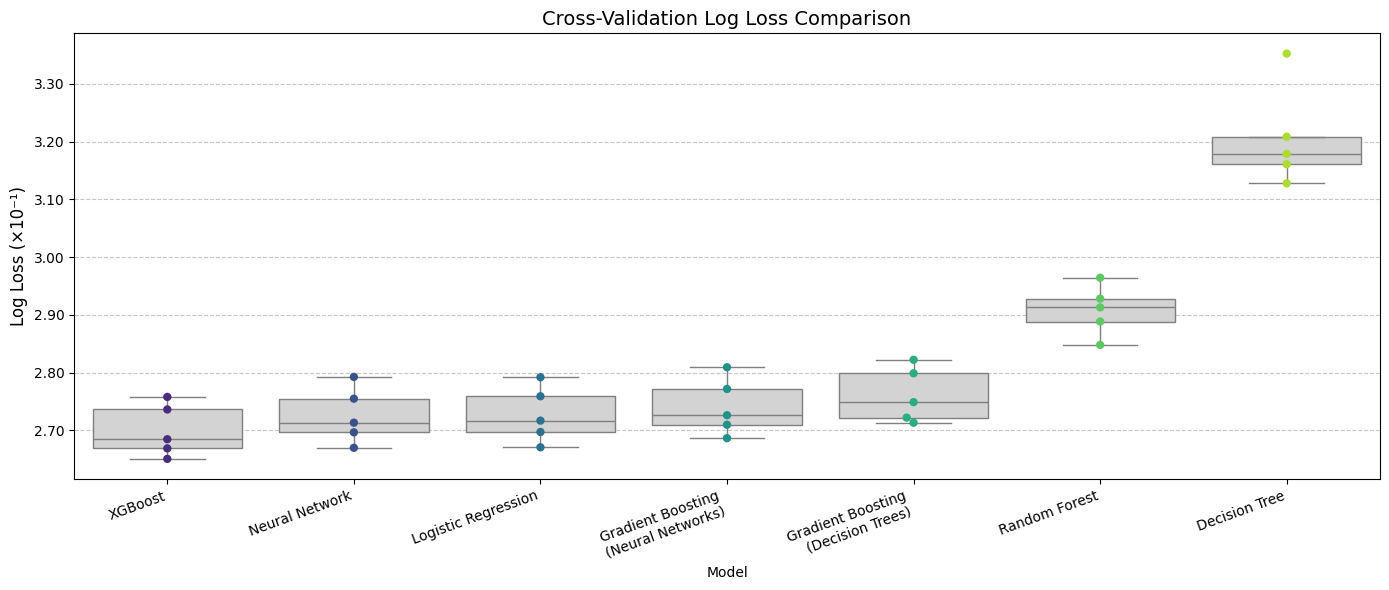

In [23]:
# 1. Prepare data
results_df = pd.DataFrame({
    'Logistic Regression': logistic_log_loss_scores,
    'Decision Tree': dt_log_loss_scores,
    'Random Forest': rf_log_loss_scores,
    'Neural Network': mlp_log_loss_scores,
    "GB (Decision Trees)": gb_log_loss_scores,
    'XGBoost': xgb_log_loss_scores,
    'GB (Neural Networks)': nn_gb_log_loss_scores
})

melted_df = results_df.melt(var_name='Model', value_name='Log Loss')

# 2. Rename with clean multi-line labels
melted_df['Model'] = melted_df['Model'].replace({
    "GB (Decision Trees)": "Gradient Boosting\n(Decision Trees)",
    "GB (Neural Networks)": "Gradient Boosting\n(Neural Networks)"
})

# 3. Order models by mean Log Loss (best → worst)
model_order = (
    melted_df.groupby('Model')['Log Loss']
    .mean()
    .sort_values()
    .index
)

# 4. Plot
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=melted_df,
    x='Model',
    y='Log Loss',
    order=model_order,
    color='lightgray',
    showfliers=False
)

sns.swarmplot(
    data=melted_df,
    x='Model',
    y='Log Loss',
    order=model_order,
    palette='viridis',
    size=6
)

# 5. Y-axis in 10^-1 scale
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x*1e1:.2f}'))
plt.ylabel('Log Loss (×10⁻¹)', fontsize=12)

# 6. Clean styling
plt.xticks(rotation=20, ha='right')
plt.title('Cross-Validation Log Loss Comparison', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

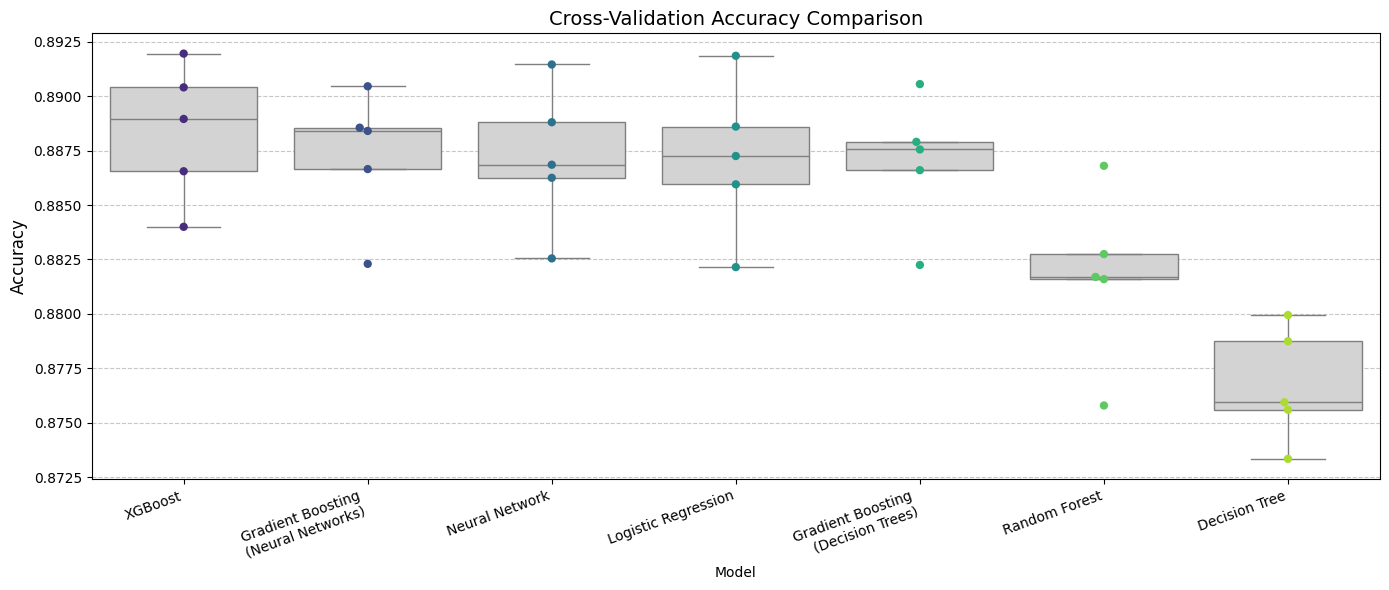

In [24]:
# 1. Prepare data
results_df = pd.DataFrame({
    'Logistic Regression': logistic_accuracy_scores,
    'Decision Tree': dt_accuracy_scores,
    'Random Forest': rf_accuracy_scores,
    'Neural Network': mlp_accuracy_scores,
    "GB (Decision Trees)": gb_accuracy_scores,
    'XGBoost': xgb_accuracy_scores,
    'GB (Neural Networks)': nn_gb_accuracy_scores
})

melted_df = results_df.melt(var_name='Model', value_name='Accuracy')

# 2. Rename with clean multi-line labels
melted_df['Model'] = melted_df['Model'].replace({
    "GB (Decision Trees)": "Gradient Boosting\n(Decision Trees)",
    "GB (Neural Networks)": "Gradient Boosting\n(Neural Networks)"
})

# 3. Order models by mean Accuracy (best [max] → worst [min])
model_order = (
    melted_df.groupby('Model')['Accuracy']
    .mean()
    .sort_values(ascending=False)
    .index
)

# 4. Plot
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=melted_df,
    x='Model',
    y='Accuracy',
    order=model_order,
    color='lightgray',
    showfliers=False
)

sns.swarmplot(
    data=melted_df,
    x='Model',
    y='Accuracy',
    order=model_order,
    palette='viridis',
    size=6
)

# 5. Y-axis - No scaling
plt.ylabel('Accuracy', fontsize=12)

# 6. Clean styling
plt.xticks(rotation=20, ha='right')
plt.title('Cross-Validation Accuracy Comparison', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### VISUALIZATION (BY MEDIAN)

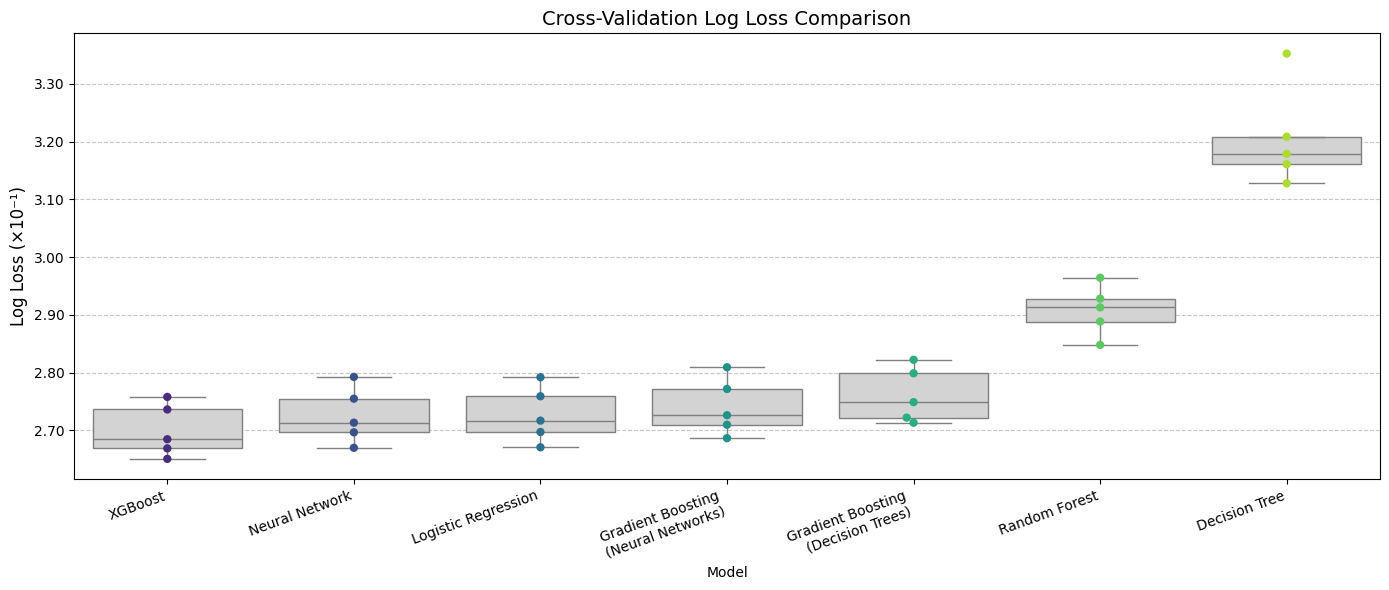

In [25]:
# 1. Prepare data
results_df = pd.DataFrame({
    'Logistic Regression': logistic_log_loss_scores,
    'Decision Tree': dt_log_loss_scores,
    'Random Forest': rf_log_loss_scores,
    'Neural Network': mlp_log_loss_scores,
    "GB (Decision Trees)": gb_log_loss_scores,
    'XGBoost': xgb_log_loss_scores,
    'GB (Neural Networks)': nn_gb_log_loss_scores
})

melted_df = results_df.melt(var_name='Model', value_name='Log Loss')

# 2. Rename with clean multi-line labels
melted_df['Model'] = melted_df['Model'].replace({
    "GB (Decision Trees)": "Gradient Boosting\n(Decision Trees)",
    "GB (Neural Networks)": "Gradient Boosting\n(Neural Networks)"
})

# 3. Order models by mean Log Loss (best → worst)
model_order = (
    melted_df.groupby('Model')['Log Loss']
    .median()
    .sort_values()
    .index
)

# 4. Plot
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=melted_df,
    x='Model',
    y='Log Loss',
    order=model_order,
    color='lightgray',
    showfliers=False
)

sns.swarmplot(
    data=melted_df,
    x='Model',
    y='Log Loss',
    order=model_order,
    palette='viridis',
    size=6
)

# 5. Y-axis in 10^-1 scale
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x*1e1:.2f}'))
plt.ylabel('Log Loss (×10⁻¹)', fontsize=12)

# 6. Clean styling
plt.xticks(rotation=20, ha='right')
plt.title('Cross-Validation Log Loss Comparison', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

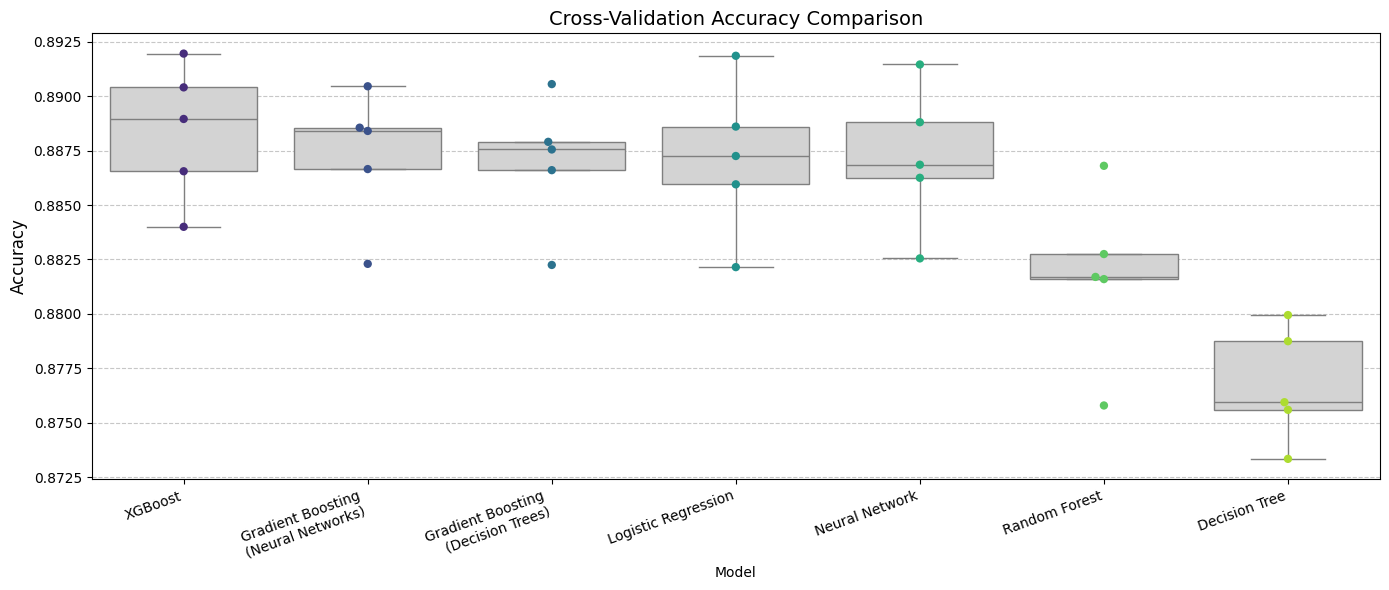

In [26]:
# 1. Prepare data
results_df = pd.DataFrame({
    'Logistic Regression': logistic_accuracy_scores,
    'Decision Tree': dt_accuracy_scores,
    'Random Forest': rf_accuracy_scores,
    'Neural Network': mlp_accuracy_scores,
    "GB (Decision Trees)": gb_accuracy_scores,
    'XGBoost': xgb_accuracy_scores,
    'GB (Neural Networks)': nn_gb_accuracy_scores
})

melted_df = results_df.melt(var_name='Model', value_name='Accuracy')

# 2. Rename with clean multi-line labels
melted_df['Model'] = melted_df['Model'].replace({
    "GB (Decision Trees)": "Gradient Boosting\n(Decision Trees)",
    "GB (Neural Networks)": "Gradient Boosting\n(Neural Networks)"
})

# 3. Order models by mean Accuracy (best [max] → worst [min])
model_order = (
    melted_df.groupby('Model')['Accuracy']
    .median()
    .sort_values(ascending=False)
    .index
)

# 4. Plot
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=melted_df,
    x='Model',
    y='Accuracy',
    order=model_order,
    color='lightgray',
    showfliers=False
)

sns.swarmplot(
    data=melted_df,
    x='Model',
    y='Accuracy',
    order=model_order,
    palette='viridis',
    size=6
)

# 5. Y-axis - No scaling
plt.ylabel('Accuracy', fontsize=12)

# 6. Clean styling
plt.xticks(rotation=20, ha='right')
plt.title('Cross-Validation Accuracy Comparison', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()